In [4]:
# PyTorch core components
import torch
import torch.nn as nn
import torch.optim as optim

# Learning rate scheduler
from torch.optim.lr_scheduler import StepLR

# Data utilities
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torchvision

# Logging and visualization
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt

# Utility libraries
import numpy as np
import random
import os


### Model

In [5]:
class DNN(nn.Module):
    def __init__(self, num_classes):
        super(DNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 512)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(512, 512)
        self.relu = nn.ReLU()
        self.fc3 = nn.Linear(512, 128)
        self.relu = nn.ReLU()
        self.fc4 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        x = self.relu(x)
        x = self.fc4(x)
        return x

In [6]:
# -------------------------
# Squeeze-and-Excitation Block
# -------------------------
# This block recalibrates channel-wise features by:
# 1. Globally pooling the spatial dimensions to compute channel descriptors.
# 2. Passing the descriptors through a small fully connected network.
# 3. Scaling the original features using the resulting channel weights.
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=4):
        super(SEBlock, self).__init__()
        # Global average pooling to create channel descriptors (shape: B x C x 1 x 1)
        self.pool = nn.AdaptiveAvgPool2d(1)
        # Two fully connected layers with a bottleneck to reduce parameters
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()  # Output scale factors in range [0, 1]
        )
    
    def forward(self, x):
        b, c, _, _ = x.size()
        # Squeeze: Reduce spatial dimensions
        y = self.pool(x).view(b, c)
        # Excite: Generate channel-wise weights
        y = self.fc(y).view(b, c, 1, 1)
        # Scale the input features
        return x * y.expand_as(x)

In [ ]:
# -------------------------
# Base Convolutional Network
# -------------------------
# The network is built using depthwise separable convolution blocks.
# - Depthwise convolution: Processes each input channel separately.
# - Pointwise convolution: Mixes the channels via 1x1 convolutions.
# Optional SE blocks can be attached to recalibrate channel responses.
class BaseConvNet(nn.Module):
    def __init__(self, num_classes=10, channels=(12, 24, 48)):
        """
        Args:
            num_classes (int): Number of output classes.
            channels (tuple): Tuple defining the number of channels at each stage.
                              Expected format: (channels_stage1, channels_stage2, channels_stage3)
        """
        super(BaseConvNet, self).__init__()

        # Utility function: Create a depthwise separable convolution block.
        # Optionally adds an SE block if use_se is True.
        def dw_conv(in_channels, out_channels, use_se=False):
            layers = [
                # Depthwise convolution: one filter per channel.
                nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1, groups=in_channels, bias=False),
                nn.BatchNorm2d(in_channels),
                nn.ReLU(inplace=True),
                # Pointwise convolution: 1x1 convolution to mix channels.
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            ]
            if use_se:
                layers.append(SEBlock(out_channels))
            return nn.Sequential(*layers)
        
        # First Stage:
        # Increase from 1 input channel (grayscale) to channels[0].
        # Apply an SE block to recalibrate early features.
        self.layer1 = dw_conv(1, channels[0], use_se=True)    # Output: (channels[0] x 28 x 28)
        self.pool1 = nn.MaxPool2d(2)  # Downsample: 28x28 -> 14x14

        # Second Stage:
        # Increase from channels[0] to channels[1], plus an extra block for additional refinement.
        self.layer2 = dw_conv(channels[0], channels[1], use_se=True)
        self.layer2_extra = dw_conv(channels[1], channels[1], use_se=False)
        self.pool2 = nn.MaxPool2d(2)  # Downsample: 14x14 -> 7x7

        # Third Stage:
        # Increase from channels[1] to channels[2] with an SE block.
        self.layer3 = dw_conv(channels[1], channels[2], use_se=True)
        
        # Global Pooling:
        # Reduce each feature map to a single value (1x1).
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        # Classifier:
        # Flattens the features, applies dropout, and outputs the class scores.
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(channels[2], num_classes)
        )

    def forward(self, x):
        # Pass input through Stage 1 and downsample.
        x = self.layer1(x)
        x = self.pool1(x)
        # Pass input through Stage 2 (main branch and extra block) and downsample.
        x = self.layer2(x)
        x = self.layer2_extra(x)
        x = self.pool2(x)
        # Pass input through Stage 3 and apply global pooling.
        x = self.layer3(x)
        x = self.global_pool(x)
        # Final classification.
        x = self.classifier(x)
        return x

In [ ]:
# -------------------------
# Dataset-Specific Models
# -------------------------
# These subclasses define models for different datasets by adjusting the channel counts.
# You can further extend or customize these classes if needed for dataset-specific pre/post-processing.
class MNISTConvNet(BaseConvNet):
    def __init__(self, num_classes=10):
        # MNIST: Less complex images, smaller capacity is sufficient.
        super(MNISTConvNet, self).__init__(num_classes=num_classes, channels=(12, 24, 48))

class KMNISTConvNet(BaseConvNet):
    def __init__(self, num_classes=10):
        # KMNIST: Slightly more complex than MNIST; use moderate capacity.
        super(KMNISTConvNet, self).__init__(num_classes=num_classes, channels=(14, 28, 56))

class FashionMNISTConvNet(BaseConvNet):
    def __init__(self, num_classes=10):
        # FashionMNIST: More variation and complexity; higher capacity is beneficial.
        super(FashionMNISTConvNet, self).__init__(num_classes=num_classes, channels=(16, 32, 64))

### Load dataset

In [9]:
def get_transforms(augment=False):
    if augment:
        return transforms.Compose([
            transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
            transforms.RandomRotation(10),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])
    else:
        return transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

In [10]:
data_dir = '/home/wins057/Documents/Projects/python-for-dl-homework/week06/data'

# Load the dataset
# Supports MNIST, FashionMNIST, KMNIST, and EMNIST
def load_data(dataset_name, batch_size=64, augment=False):
    transform = get_transforms(augment)

    if dataset_name == "MNIST":
        train_set = datasets.MNIST(root=data_dir, train=True, transform=transform, download=True)
        test_set = datasets.MNIST(root=data_dir, train=False, transform=transform, download=True)
    elif dataset_name == "FashionMNIST":
        train_set = datasets.FashionMNIST(root=data_dir, train=True, transform=transform, download=True)
        test_set = datasets.FashionMNIST(root=data_dir, train=False, transform=transform, download=True)
    elif dataset_name == "KMNIST":
        train_set = datasets.KMNIST(root=data_dir, train=True, transform=transform, download=True)
        test_set = datasets.KMNIST(root=data_dir, train=False, transform=transform, download=True)
    elif dataset_name == "EMNIST":
        train_set = datasets.EMNIST(root=data_dir, split='balanced', train=True, transform=transform, download=True)
        test_set = datasets.EMNIST(root=data_dir, split='balanced', train=False, transform=transform, download=True)
    else:
        raise ValueError("Unsupported dataset name.")
    
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

### Parameters Count

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:
model = DNN(num_classes=10)
print(f"{count_parameters(model)} parameters in DNN model")
model = MNISTConvNet(num_classes=10)
print(f"{count_parameters(model)} parameters in MNISTConvNet model")
model = KMNISTConvNet(num_classes=10)
print(f"{count_parameters(model)} parameters in KMNISTConvNet model")
model = FashionMNISTConvNet(num_classes=10)
print(f"{count_parameters(model)} parameters in FashionMNISTConvNet model")

### Train and Evaluate Function

In [11]:
# Evaluate the model
# Computes accuracy on test set
def evaluate_model(model, test_loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return correct / total

In [12]:
def log_tensorboard(writer, model, train_loader, dataset_name):
    example_images, _ = next(iter(train_loader))
    writer.add_graph(model, example_images.to(next(model.parameters()).device))
    img_grid = torchvision.utils.make_grid(example_images[:16])
    writer.add_image(f"{dataset_name}_examples", img_grid)

In [31]:
# Train the model
# Saves the best model based on validation accuracy
# Logs training metrics to TensorBoard
def train_model(model, train_loader, test_loader, dataset_name="MNIST", epochs=10, lr=0.001, log_dir="runs"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = StepLR(optimizer, step_size=50, gamma=0.5)

    writer = SummaryWriter(log_dir=os.path.join(log_dir, dataset_name))
    log_tensorboard(writer, model, train_loader, dataset_name)
    model_name = model.__class__.__name__
    checkpoint_dir = os.path.join(f"checkpoints", dataset_name)
    checkpoint_dir = os.path.join(checkpoint_dir, model_name)
    os.makedirs(checkpoint_dir, exist_ok=True)
    saved_model_accs = {}

    for epoch in range(epochs):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0

        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

            step = epoch * len(train_loader) + i
            if i % 100 == 99:
                writer.add_scalar("Loss/Train", running_loss / 100, step)
                running_loss = 0.0
            if step % 300 == 0:
                for name, param in model.named_parameters():
                    writer.add_histogram(name, param, step)

        train_acc = correct_train / total_train
        val_acc = evaluate_model(model, test_loader, device)
        scheduler.step()
        writer.add_scalars("Accuracy", {"Train": train_acc, "Validation": val_acc}, epoch)
        print(f"[{dataset_name}] Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")
            
        # Save the model every i epochs
        if (epoch + 1) % 10 == 0:
            filename = f"epoch_{epoch+1}.pth"
            save_path = os.path.join(checkpoint_dir, filename)
            torch.save(model.state_dict(), save_path)
            saved_model_accs[filename] = val_acc
            print(f"📦 Saved model to {filename} with accuracy {val_acc:.4f}")
    
    print(f"\n📊 Saved models & Accuracies: \n{saved_model_accs}")
    
    # Select the best model based on validation accuracy
    if saved_model_accs:
        best_filename = max(saved_model_accs, key=lambda k: saved_model_accs[k])
        best_acc = saved_model_accs[best_filename]
        best_model_path = os.path.join(checkpoint_dir, "best_model.pth")
        torch.save(torch.load(os.path.join(checkpoint_dir, best_filename)), best_model_path)
        print(f"\n✅ Saved best model to {best_filename} with accuracy {best_acc:.4f}")
    
        model.load_state_dict(torch.load(best_model_path))
        model = model.to(device)
        model.eval()

    writer.close()
    return model

### Visualization

In [ ]:
# Displays a grid of images with predicted and ground truth labels
# Highlights misclassified examples in red
def visualize_results(model, test_loader, class_names=None, num_images=10):
    model.eval()
    device = next(model.parameters()).device
    images, labels = next(iter(test_loader))
    images, labels = images.to(device), labels.to(device)

    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

    images = images.cpu().numpy()
    predicted = predicted.cpu().numpy()
    labels = labels.cpu().numpy()

    plt.figure(figsize=(num_images * 1.8, 2.5))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[i][0], cmap='gray')
        plt.axis('off')

        pred = predicted[i]
        gt = labels[i]
        
        if class_names:
            pred_text = class_names[pred]
            gt_text = class_names[gt]
        else:
            pred_text = str(pred)
            gt_text = str(gt)

        # Highlight misclassified examples
        title_color = 'green' if pred == gt else 'red'
        plt.title(f"P:{pred_text}\nGT:{gt_text}", fontsize=8, color=title_color)

    plt.suptitle("Test Predictions vs Ground Truth")
    plt.tight_layout()
    plt.show()

In [ ]:
def get_class_names(dataset_name):
    if dataset_name == "FashionMNIST":
        return ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
    
    elif dataset_name == "EMNIST":
        return [
            '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
            'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J',
            'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T',
            'U', 'V', 'W', 'X', 'Y', 'Z',
            'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't'
        ]

    elif dataset_name == "KMNIST":
        return ['o', 'ki', 'su', 'tsu', 'na', 'ha', 'ma', 'ya', 're', 'wo']
        # These correspond to 10 Hiragana characters in the order of the labels
    
    return None  # For MNIST or others

In [20]:
def visualize_config(model, dataset_name, lr, epochs):
    print("============================================================")
    print(f"Model: {model.__class__.__name__}")
    print(f"Number of parameters: {count_parameters(model)}")
    print(f"Dataset: {dataset_name}")
    print(f"Learning Rate: {lr}")
    print(f"Epochs: {epochs}")
    print("============================================================")
    print("Training...")

## Training

In [ ]:
def run_training_pipeline(dataset_name="MNIST", epochs=5, lr=0.001, DNN_model=False):
    """
    This is the main function to run the training pipeline.
    It initializes the model, loads the dataset, trains the model,
    and visualizes the results.
    Args:
        dataset_name (str): Name of the dataset to use. Options: "MNIST", "FashionMNIST", "KMNIST", "EMNIST".
        epochs (int): Number of training epochs.
        lr (float): Learning rate for the optimizer.
        DNN_model (bool): If True, use a simple DNN model instead of convolutional networks.
    """
    # Create the model
    num_classes = 47 if dataset_name == "EMNIST" else 10
    if DNN_model:
        # Use DNN model
        model = DNN(num_classes=num_classes)
    else:
        if dataset_name == "MNIST":
            # Use MNIST-specific model
            model = MNISTConvNet(num_classes=num_classes)
        elif dataset_name == "KMNIST":
            # Use KMNIST-specific model
            model = KMNISTConvNet(num_classes=num_classes)
        elif dataset_name == "FashionMNIST":
            # Use FashionMNIST-specific model
            model = FashionMNISTConvNet(num_classes=num_classes)
        else:
            model = BaseConvNet(num_classes=num_classes, channels=(16, 32, 64))

    # Conifgure training
    visualize_config(model, dataset_name, lr, epochs)
    
    # Load dataset
    train_loader, test_loader = load_data(dataset_name, 64, False)

    # Train model
    best_model = train_model(model, train_loader, test_loader, dataset_name, epochs=epochs, lr=lr)

    # Visualize results
    class_names = get_class_names(dataset_name)
    visualize_results(best_model, test_loader, class_names=class_names)

### MNIST Training

Model: MNISTConvNet
Number of parameters: 4917
Dataset: MNIST
Learning Rate: 0.001
Epochs: 180
Training...
[MNIST] Epoch 1: Train Acc=0.7506, Val Acc=0.9427
[MNIST] Epoch 2: Train Acc=0.9324, Val Acc=0.9578
[MNIST] Epoch 3: Train Acc=0.9465, Val Acc=0.9623
[MNIST] Epoch 4: Train Acc=0.9554, Val Acc=0.9662
[MNIST] Epoch 5: Train Acc=0.9606, Val Acc=0.9719
[MNIST] Epoch 6: Train Acc=0.9645, Val Acc=0.9735
[MNIST] Epoch 7: Train Acc=0.9668, Val Acc=0.9747
[MNIST] Epoch 8: Train Acc=0.9693, Val Acc=0.9757
[MNIST] Epoch 9: Train Acc=0.9711, Val Acc=0.9778
[MNIST] Epoch 10: Train Acc=0.9729, Val Acc=0.9759
📦 Saved model to epoch_10.pth with accuracy 0.9759
[MNIST] Epoch 11: Train Acc=0.9747, Val Acc=0.9767
[MNIST] Epoch 12: Train Acc=0.9752, Val Acc=0.9786
[MNIST] Epoch 13: Train Acc=0.9765, Val Acc=0.9781
[MNIST] Epoch 14: Train Acc=0.9775, Val Acc=0.9788
[MNIST] Epoch 15: Train Acc=0.9778, Val Acc=0.9791
[MNIST] Epoch 16: Train Acc=0.9794, Val Acc=0.9780
[MNIST] Epoch 17: Train Acc=0.9789,

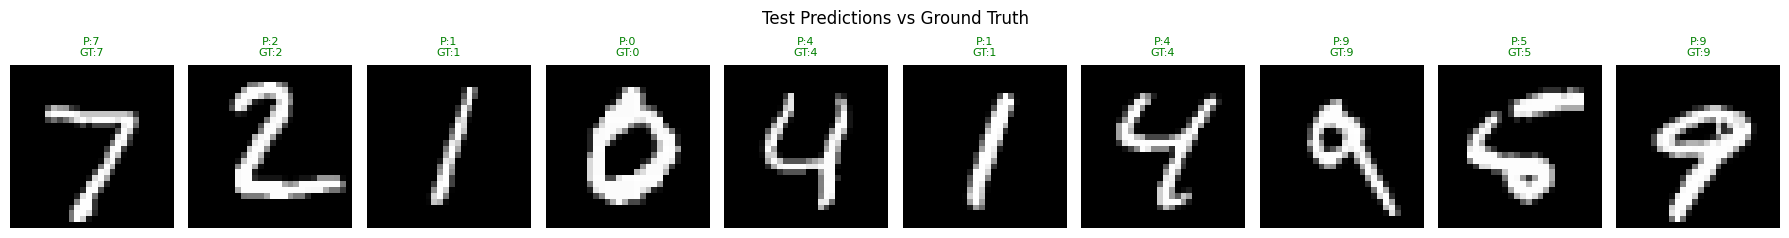

In [ ]:
# Must have Accuracy ~98.06% - 98.67% 
run_training_pipeline(dataset_name="MNIST", epochs=100, lr=0.001, DNN_model=False)

### KMNIST

Model: KMNISTConvNet
Number of parameters: 6405
Dataset: KMNIST
Learning Rate: 0.001
Epochs: 180
Training...
[KMNIST] Epoch 1: Train Acc=0.6664, Val Acc=0.6745
[KMNIST] Epoch 2: Train Acc=0.8403, Val Acc=0.7573
[KMNIST] Epoch 3: Train Acc=0.8737, Val Acc=0.7883
[KMNIST] Epoch 4: Train Acc=0.8932, Val Acc=0.7905
[KMNIST] Epoch 5: Train Acc=0.9066, Val Acc=0.8057
[KMNIST] Epoch 6: Train Acc=0.9136, Val Acc=0.8294
[KMNIST] Epoch 7: Train Acc=0.9230, Val Acc=0.8359
[KMNIST] Epoch 8: Train Acc=0.9278, Val Acc=0.8491
[KMNIST] Epoch 9: Train Acc=0.9323, Val Acc=0.8494
[KMNIST] Epoch 10: Train Acc=0.9351, Val Acc=0.8654
📦 Saved model to epoch_10.pth with accuracy 0.8654
[KMNIST] Epoch 11: Train Acc=0.9392, Val Acc=0.8529
[KMNIST] Epoch 12: Train Acc=0.9414, Val Acc=0.8570
[KMNIST] Epoch 13: Train Acc=0.9447, Val Acc=0.8725
[KMNIST] Epoch 14: Train Acc=0.9472, Val Acc=0.8735
[KMNIST] Epoch 15: Train Acc=0.9476, Val Acc=0.8727
[KMNIST] Epoch 16: Train Acc=0.9511, Val Acc=0.8731
[KMNIST] Epoch 17

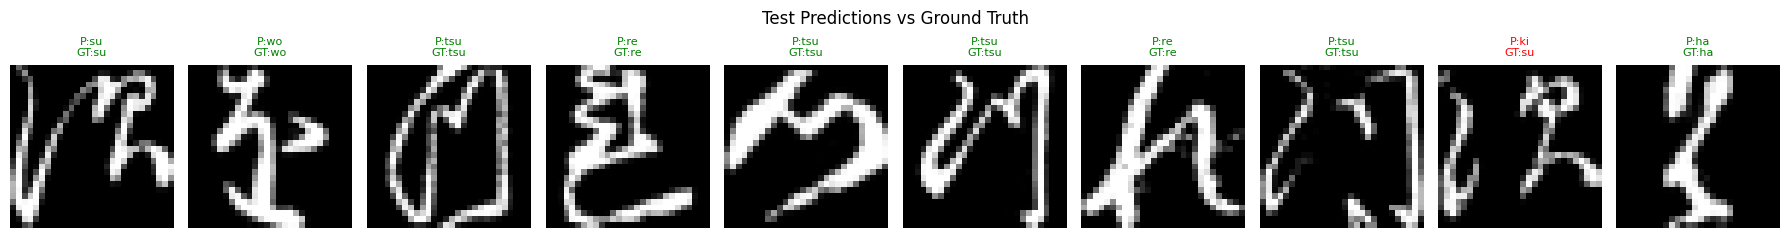

In [ ]:
# Must have Accuracy ~91.09% - 93.18%
run_training_pipeline(dataset_name="KMNIST", epochs=150, lr=0.001, DNN_model=False)

### Fashion MNIST

Model: FashionMNISTConvNet
Number of parameters: 8117
Dataset: FashionMNIST
Learning Rate: 0.001
Epochs: 180
Training...
[FashionMNIST] Epoch 1: Train Acc=0.7082, Val Acc=0.7943
[FashionMNIST] Epoch 2: Train Acc=0.8167, Val Acc=0.8024
[FashionMNIST] Epoch 3: Train Acc=0.8308, Val Acc=0.8431
[FashionMNIST] Epoch 4: Train Acc=0.8415, Val Acc=0.8428
[FashionMNIST] Epoch 5: Train Acc=0.8478, Val Acc=0.8550
[FashionMNIST] Epoch 6: Train Acc=0.8527, Val Acc=0.8530
[FashionMNIST] Epoch 7: Train Acc=0.8579, Val Acc=0.8592
[FashionMNIST] Epoch 8: Train Acc=0.8591, Val Acc=0.8645
[FashionMNIST] Epoch 9: Train Acc=0.8651, Val Acc=0.8586
[FashionMNIST] Epoch 10: Train Acc=0.8661, Val Acc=0.8627
📦 Saved model to epoch_10.pth with accuracy 0.8627
[FashionMNIST] Epoch 11: Train Acc=0.8691, Val Acc=0.8644
[FashionMNIST] Epoch 12: Train Acc=0.8716, Val Acc=0.8719
[FashionMNIST] Epoch 13: Train Acc=0.8714, Val Acc=0.8661
[FashionMNIST] Epoch 14: Train Acc=0.8745, Val Acc=0.8703
[FashionMNIST] Epoch 15: 

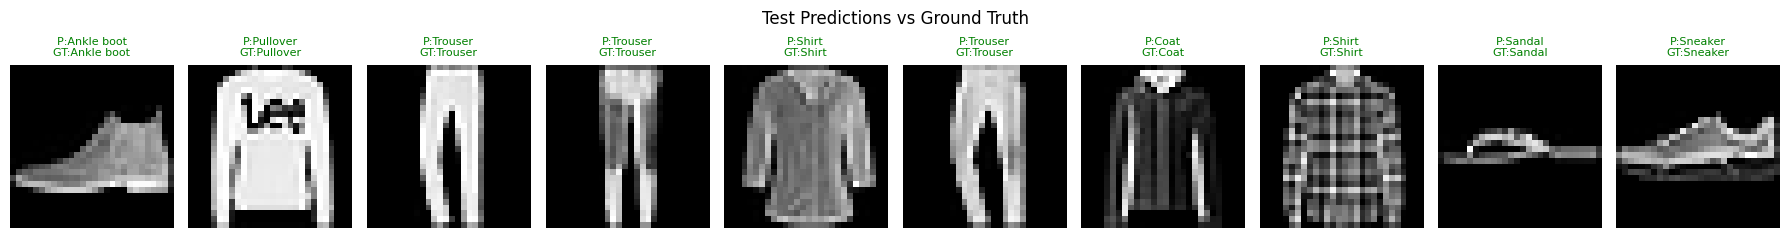

In [ ]:
# Must have Accuracy ~88.69% - 88.90%
run_training_pipeline(dataset_name="FashionMNIST", epochs=150, lr=0.001, DNN_model=False)

### Tensorboard

In [28]:
%load_ext tensorboard
%tensorboard --logdir=runs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [30]:
%reload_ext tensorboard

In [27]:
!kill 462979